In [1]:
# This code works in Python 3.10.6
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import torch_geometric.utils.convert
import random
import dgl
import torch
from torch import optim
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, Linear, SAGEConv
import seaborn as sns
import glob
import itertools
import community as community_louvain
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')

Create Metagraph

In [2]:
import import_ipynb
#PubMed dataset with all features
import pubmed_dataset

importing Jupyter notebook from pubmed_dataset.ipynb
HeteroData(
  disease={
    x=[454, 200],
    y=[454],
  },
  gene={ x=[13561, 200] },
  chemical={ x=[26522, 200] },
  species={ x=[2863, 200] },
  (gene, to, gene)={ edge_index=[2, 40] },
  (gene, to, disease)={ edge_index=[2, 1] },
  (chemical, to, gene)={ edge_index=[2, 70] },
  (chemical, to, chemical)={ edge_index=[2, 108] },
  (chemical, to, species)={ edge_index=[2, 18] },
  (species, to, gene)={ edge_index=[2, 6] }
)


In [3]:
data = pubmed_dataset.data

In [4]:
dataset = data.clone()
# Node features are removed as a temporary fix to the errors in conversion of 
#Pytorch Geometric HeteroData to DGL graph. Node features are not important for creating metagraph.
dataset['disease'].x = dataset['disease'].x[:405, :]
dataset['disease'].y = dataset['disease'].y[:405]
dataset['gene'].x = dataset['gene'].x[:13499, :]
dataset['chemical'].x = dataset['chemical'].x[:26406, :]
dataset['species'].x = dataset['species'].x[:2741, :]

In [5]:
#Create metagraph
g = torch_geometric.utils.convert.to_dgl(dataset)
meta_g= g.metagraph()

In [6]:
#PubMed dataset with selected features used for GNN training
data

HeteroData(
  disease={
    x=[454, 200],
    y=[454],
  },
  gene={ x=[13561, 200] },
  chemical={ x=[26522, 200] },
  species={ x=[2863, 200] },
  (gene, to, gene)={ edge_index=[2, 40] },
  (gene, to, disease)={ edge_index=[2, 1] },
  (chemical, to, gene)={ edge_index=[2, 70] },
  (chemical, to, chemical)={ edge_index=[2, 108] },
  (chemical, to, species)={ edge_index=[2, 18] },
  (species, to, gene)={ edge_index=[2, 6] }
)

In [7]:
transform = T.RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)
data = transform(data)
data

HeteroData(
  disease={
    x=[454, 200],
    y=[454],
    train_mask=[454],
    val_mask=[454],
    test_mask=[454],
  },
  gene={ x=[13561, 200] },
  chemical={ x=[26522, 200] },
  species={ x=[2863, 200] },
  (gene, to, gene)={ edge_index=[2, 40] },
  (gene, to, disease)={ edge_index=[2, 1] },
  (chemical, to, gene)={ edge_index=[2, 70] },
  (chemical, to, chemical)={ edge_index=[2, 108] },
  (chemical, to, species)={ edge_index=[2, 18] },
  (species, to, gene)={ edge_index=[2, 6] }
)

In [8]:
class HeteroGNN(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                edge_type: SAGEConv((-1, -1), hidden_channels)
                for edge_type in metadata[1]
            })
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: F.leaky_relu(x) for key, x in x_dict.items()}
        return self.lin(x_dict['disease'])


def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    mask = data['disease'].train_mask
    loss = F.cross_entropy(out[mask], data['disease'].y[mask])
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def test():
    model.eval()
    pred = model(data.x_dict, data.edge_index_dict).argmax(dim=-1)

    accs = []
    for split in ['train_mask', 'val_mask', 'test_mask']:
        mask = data['disease'][split]
        acc = (pred[mask] == data['disease'].y[mask]).sum() / mask.sum()
        accs.append(float(acc))
    return accs


importing Jupyter notebook from pubmed_gmm_features.ipynb
no of class disease0 node samples - 80
no of class disease1 node samples - 80
no of class disease2 node samples - 80
no of class disease3 node samples - 80
no of class disease4 node samples - 80
no of class disease5 node samples - 80
no of class disease6 node samples - 80
no of class disease7 node samples - 80
no of class gene node samples - 80
no of class chemical node samples - 80
no of class species node samples - 80


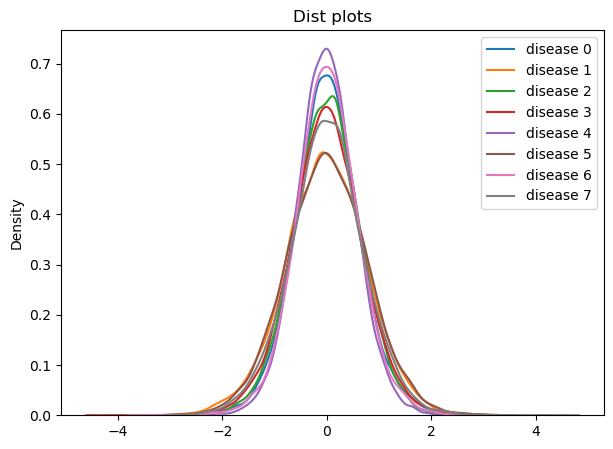

In [9]:
#Load node features 
import pubmed_gmm_features

In [10]:
class0  = pubmed_gmm_features.disease0_sampled
class1  = pubmed_gmm_features.disease1_sampled
class2  = pubmed_gmm_features.disease2_sampled
class3  = pubmed_gmm_features.disease3_sampled
class4  = pubmed_gmm_features.disease4_sampled
class5  = pubmed_gmm_features.disease5_sampled
class6  = pubmed_gmm_features.disease6_sampled
class7  = pubmed_gmm_features.disease7_sampled

gene  = pubmed_gmm_features.gene_node_features
chemical  = pubmed_gmm_features.chemical_node_features
species  = pubmed_gmm_features.species_node_features

df_class0=class0
df_class0=df_class0.reset_index(drop=True)
df_class1=class1
df_class1=df_class1.reset_index(drop=True)
df_class2=class2
df_class2=df_class2.reset_index(drop=True)
df_class3=class3
df_class3=df_class3.reset_index(drop=True)
df_class4=class4
df_class4=df_class4.reset_index(drop=True)
df_class5=class5
df_class5=df_class5.reset_index(drop=True)
df_class6=class6
df_class6=df_class6.reset_index(drop=True)
df_class7=class7
df_class7=df_class7.reset_index(drop=True)

In [11]:
def get_node_features(G):
    nodes = []
    gene_node_features = []
    disease_node_features = []
    disease_class = []
    chemical_node_features = []
    species_node_features = []
    
    for key, value in G.nodes(data=True):
        nodes.append(key)
        edges = [e for e in G.edges]

        node_type = G.nodes[key]["node_type"]
        if node_type == 0:
            node_id = G.nodes[key]["label"]
            gene_node = gene.loc[int(node_id), :].values.flatten().tolist()
            gene_node_features.append(gene_node)
        elif node_type == 1:
            node_class = random.choice([0, 1, 2, 3, 4, 5, 6, 7])
            if node_class == 0:
                node_id = G.nodes[key]["label"]
                disease_node = df_class0.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(0)
                disease_node_features.append(disease_node)
            elif node_class == 1:
                node_id = G.nodes[key]["label"]
                disease_node = df_class1.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(1)
                disease_node_features.append(disease_node)
            elif node_class == 2:
                node_id = G.nodes[key]["label"]
                disease_node = df_class2.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(2)
                disease_node_features.append(disease_node)
            elif node_class == 3:
                node_id = G.nodes[key]["label"]
                disease_node = df_class3.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(3)
                disease_node_features.append(disease_node)
            elif node_class == 4:
                node_id = G.nodes[key]["label"]
                disease_node = df_class4.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(4)
                disease_node_features.append(disease_node)
            elif node_class == 5:
                node_id = G.nodes[key]["label"]
                disease_node = df_class5.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(5)
                disease_node_features.append(disease_node)
            elif node_class == 6:
                node_id = G.nodes[key]["label"]
                disease_node = df_class6.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(6)
                disease_node_features.append(disease_node)
            elif node_class == 7:
                node_id = G.nodes[key]["label"]
                disease_node = df_class7.loc[int(node_id), :].values.flatten().tolist()
                disease_class.append(7)
                disease_node_features.append(disease_node)

        elif node_type == 2:
            node_id = G.nodes[key]["label"]
            chemical_node = chemical.loc[int(node_id), :].values.flatten().tolist()
            chemical_node_features.append(chemical_node)
        elif node_type == 3:
            node_id = G.nodes[key]["label"]
            species_node = species.loc[int(node_id), :].values.flatten().tolist()
            species_node_features.append(species_node)

        disease_node_features_df = pd.DataFrame(disease_node_features)
        disease_node_features_df['class'] = disease_class
        gene_node_features_df = pd.DataFrame(gene_node_features)
        chemical_node_features_df = pd.DataFrame(chemical_node_features)
        species_node_features_df = pd.DataFrame(species_node_features)

    return nodes, edges, disease_node_features_df, gene_node_features_df, chemical_node_features_df, species_node_features_df


In [12]:
def remap_indices(node_list):
    val_list = [*range(0, len(node_list), 1)]
    return dict(zip(node_list,val_list))  

In [13]:
def preprocess_edges(edgelist,node_list):
    res = [[node_list[i] for i, j in edgelist],[node_list[j] for i, j in edgelist]] 
    node_from = torch.tensor(res[0])
    node_to = torch.tensor(res[1])
    edges = torch.concat((node_from,node_to)).reshape(-1,len(node_from))
    return edges

In [14]:
def get_node_type(node_type):
    if node_type == 1:
        return 'disease'
    elif node_type == 0:
        return 'gene'
    elif node_type == 2:
        return 'chemical'
    elif node_type == 3:
        return 'species'

In [15]:
#List of edges in metagraph of PubMed
list(meta_g.edges())

[('chemical', 'chemical'),
 ('chemical', 'gene'),
 ('chemical', 'species'),
 ('gene', 'disease'),
 ('gene', 'gene'),
 ('species', 'gene')]

In [16]:
def create_dataset(nodes,edges,disease_df,gene_df,chemical_df,species_df,node_id,df_graph):
    disease = np.asarray(disease_df.drop(columns=['class']))
    gene = np.asarray(gene_df)
    chemical = np.asarray(chemical_df)
    species = np.asarray(species_df)
    
    x_disease = torch.tensor(disease).to(dtype=torch.float32)
    y_disease = torch.tensor(np.array(disease_df["class"]), dtype=torch.long)
    x_gene = torch.tensor(gene).to(dtype=torch.float32)
    x_chemical = torch.tensor(chemical).to(dtype=torch.float32)
    x_species = torch.tensor(species).to(dtype=torch.float32)

    #Edges
    source,dest =list(map(list, zip(*edges)))

    gene_to_gene = []
    gene_to_disease = []
    disease_to_disease = []
    chemical_to_gene = []
    chemical_to_disease = []
    chemical_to_chemical = []
    chemical_to_species = []
    species_to_gene = []
    species_to_disease = []
    species_to_species = []
    
    remaining_edges = []

    class_dict = {'Gene':0, 'Disease':1, 'Chemical':2,'Species':3}

    for i in range(len(edges)):
        if (df_graph.iloc[int(source[i])]['class'] == class_dict['Gene']) and \
        (df_graph.iloc[int(dest[i])]['class'] == class_dict['Gene']):
                gene_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Gene']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Disease']):
                gene_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Disease']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Disease']):
                disease_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Chemical']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Gene']):
                chemical_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Chemical']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Disease']):
                chemical_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Chemical']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Chemical']):
                chemical_to_chemical.append((int(source[i]),int(dest[i])))
                
        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Chemical']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Species']):
                chemical_to_species.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Species']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Gene']):
                species_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Species']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Disease']):
                species_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Species']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Species']):
                species_to_species.append((int(source[i]),int(dest[i])))

        else:
            source_node_type = get_node_type(df_graph.iloc[int(source[i])]['class'])
            dest_node_type = get_node_type(df_graph.iloc[int(dest[i])]['class'])
            remaining_edges.append((source_node_type,dest_node_type))
            #remaining_edges.append((int(source[i]),int(dest[i])))
            
    all_edges[node_id] = [*gene_to_gene,*gene_to_disease,*disease_to_disease,*chemical_to_gene,
                          *chemical_to_disease,*chemical_to_chemical,*chemical_to_species, *species_to_gene, 
                          *species_to_disease, *species_to_species]
            
    disease = list(df_graph[df_graph['class'] == 1]['nodeId'])
    disease = [int(i) for i in disease]
    disease_nodes_mapping = remap_indices(disease)
    
    gene = list(df_graph[df_graph['class'] == 0]['nodeId'])
    gene = [int(i) for i in gene]
    gene_nodes_mapping = remap_indices(gene)
    
    chemical = list(df_graph[df_graph['class'] == 2]['nodeId'])
    chemical = [int(i) for i in chemical]
    chemical_nodes_mapping = remap_indices(chemical)
    
    species = list(df_graph[df_graph['class'] == 3]['nodeId'])
    species = [int(i) for i in species]
    species_nodes_mapping = remap_indices(species)


    node_list = {}
    for d in [disease_nodes_mapping, gene_nodes_mapping, chemical_nodes_mapping,species_nodes_mapping]:
        node_list.update(d)           

    #Create Hetero Data      
    small_graph = HeteroData({'disease':{'x': x_disease, 'y':y_disease}, 'gene':{'x': x_gene},
                              'chemical':{'x': x_chemical}, 'species':{'x': x_species}})

    if gene_to_gene:
        edge_index_gene_gene = preprocess_edges(gene_to_gene,node_list)
        small_graph['gene','to','gene'].edge_index = edge_index_gene_gene
    if gene_to_disease:
        edge_index_gene_disease = preprocess_edges(gene_to_disease,node_list)
        small_graph['gene','to','disease'].edge_index = edge_index_gene_disease
    if disease_to_disease:
        edge_index_disease_disease = preprocess_edges(disease_to_disease,node_list)
        small_graph['disease','to','disease'].edge_index = edge_index_disease_disease
    if chemical_to_gene:
        edge_index_chemical_gene = preprocess_edges(chemical_to_gene,node_list)
        small_graph['chemical','to','gene'].edge_index = edge_index_chemical_gene
    if chemical_to_disease:
        edge_index_chemical_disease = preprocess_edges(chemical_to_disease,node_list)
        small_graph['chemical','to','disease'].edge_index = edge_index_chemical_disease
    if chemical_to_chemical:
        edge_index_chemical_chemical = preprocess_edges(chemical_to_chemical,node_list)
        small_graph['chemical','to','chemical'].edge_index = edge_index_chemical_chemical
    if chemical_to_species:
        edge_index_chemical_species = preprocess_edges(chemical_to_species,node_list)
        small_graph['chemical','to','species'].edge_index = edge_index_chemical_species
    if species_to_gene:
        edge_index_species_gene = preprocess_edges(species_to_gene,node_list)
        small_graph['species','to','gene'].edge_index = edge_index_species_gene
    if species_to_disease:
        edge_index_species_disease = preprocess_edges(species_to_disease,node_list)
        small_graph['species','to','disease'].edge_index = edge_index_species_disease
    if species_to_species:
        edge_index_species_species = preprocess_edges(species_to_species,node_list)
        small_graph['species','to','species'].edge_index = edge_index_species_species

    transform = T.Constant(node_types='conference')
    small_graph = transform(small_graph)
    
    #Removing isolated nodes
    transform = T.Compose([T.remove_isolated_nodes.RemoveIsolatedNodes()])
    small_graph = transform(small_graph)

    #Adding test mask for prediction
    transform = T.RandomNodeSplit(split='train_rest', num_val=0.0, num_test=1.0)
    small_graph = transform(small_graph)
       
    return small_graph, remaining_edges

In [17]:
def evaluate_gnn(small_graph):
    with torch.no_grad():
        model.eval()
        #The pred is not used for accuracy, the softmax is used
        pred = model(small_graph.x_dict, small_graph.edge_index_dict).argmax(dim=-1)
        
        #Getting class prediction probabilities from the softmax layer
        softmax = model(small_graph.x_dict, small_graph.edge_index_dict).softmax(dim=-1)
        
        mask = small_graph['disease'].test_mask
        correct = (pred[mask] == small_graph['disease'].y[mask])
        
        correct_indices = [i for i, x in enumerate(correct.tolist()) if x]
        
        #Taking softmax values of the nodes for which prediction is correct
        softmax_pred_list = [softmax.tolist()[i] for i in correct_indices]
        
        return softmax_pred_list, correct_indices

In [18]:
def detect_community(G):
    partition = community_louvain.best_partition(G)

In [19]:
# import os 

# path = '../sampled_graphs/pubmed' 

# files = os.listdir(path) 
# counter = 0
# for index, file in enumerate(files):
    
#     if file.endswith('.gexf'):
#         counter+=1
#         os.rename(os.path.join(path, file), os.path.join(path, ''.join([str(counter), '.gexf'])))

In [20]:
print('Original no of graphs:',len([name for name in glob.iglob('pubmed_10to15/*.gexf')]))

Original no of graphs: 1385


In [21]:
avg_max_pred_list = []
max_pred_list = []
graph_dict_list = []
softmax_dict_list = []
nodefeature_dict_list = []
all_edges_list = []
class_graphid_list = []

In [22]:
def get_max_pred(softmax_dict,i):
    #Getting the list of predictions for each class
    prob_class0_dict = {}
    prob_class1_dict = {}
    prob_class2_dict = {}
    prob_class3_dict = {}
    prob_class4_dict = {}
    prob_class5_dict = {}
    prob_class6_dict = {}
    prob_class7_dict = {}
    for nodeid in softmax_dict:
        list0= []
        list1= []
        list2= []
        list3= []
        list4= []
        list5= []
        list6= []
        list7= []
    
        if len(softmax_dict[nodeid]) > 0:
            list0= []
            list1= []
            list2= []
            list3= []
            list4= []
            list5= []
            list6= []
            list7= []
    
            for prob in softmax_dict[nodeid]:        
                list0.append(prob[0])        
                list1.append(prob[1]) 
                list2.append(prob[2]) 
                list3.append(prob[3])
                list4.append(prob[4])
                list5.append(prob[5])
                list6.append(prob[6])
                list7.append(prob[7])
    
         #Taking max probability of all nodes of each class in a graph
        if len(list0) != 0:
            prob_class0_dict[nodeid]=max(list0)
        if len(list1) != 0:
            prob_class1_dict[nodeid]=max(list1)
        if len(list2) != 0:
            prob_class2_dict[nodeid]=max(list2)
        if len(list3) != 0:
            prob_class3_dict[nodeid]=max(list3)
        if len(list4) != 0:
            prob_class4_dict[nodeid]=max(list4)
        if len(list5) != 0:
            prob_class5_dict[nodeid]=max(list5)
        if len(list6) != 0:
            prob_class6_dict[nodeid]=max(list6)
        if len(list7) != 0:
            prob_class7_dict[nodeid]=max(list7)

    max_pred0 = max(prob_class0_dict.values())
    max_pred1 = max(prob_class1_dict.values())
    max_pred2 = max(prob_class2_dict.values())
    max_pred3 = max(prob_class3_dict.values())
    max_pred4 = max(prob_class4_dict.values())
    max_pred5 = max(prob_class5_dict.values())
    max_pred6 = max(prob_class6_dict.values())
    max_pred7 = max(prob_class7_dict.values())

    print('Run'+str(i), max_pred0, max_pred1, max_pred2, max_pred3,max_pred4, max_pred5, max_pred6, max_pred7)
    max_pred_list.append([max_pred0, max_pred1, max_pred2, max_pred3,max_pred4, max_pred5, max_pred6, max_pred7])

    graph_dict_list.append(graph_dict)
    all_edges_list.append(all_edges)
    softmax_dict_list.append(softmax_dict)
    nodefeature_dict_list.append(nodefeature_dict)
    
    avg_max_pred = (max_pred0+max_pred1+max_pred2+max_pred3+max_pred4+max_pred5+max_pred6+max_pred7)/8
    avg_max_pred_list.append(avg_max_pred)
    
    class0_graphid = max(prob_class0_dict, key=prob_class0_dict.get)
    class1_graphid = max(prob_class1_dict, key=prob_class1_dict.get)
    class2_graphid = max(prob_class2_dict, key=prob_class2_dict.get)
    class3_graphid = max(prob_class3_dict, key=prob_class3_dict.get)
    class4_graphid = max(prob_class4_dict, key=prob_class4_dict.get)
    class5_graphid = max(prob_class5_dict, key=prob_class5_dict.get)
    class6_graphid = max(prob_class6_dict, key=prob_class6_dict.get)
    class7_graphid = max(prob_class7_dict, key=prob_class7_dict.get)

    class_graphid_list.append([class0_graphid,class1_graphid,class2_graphid,class3_graphid,class4_graphid,class5_graphid,class6_graphid,class7_graphid])

In [23]:
for i in range(0,10):
    model = HeteroGNN(data.metadata(), hidden_channels=256, out_channels=8,
                      num_layers=4)
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = 'cpu'
    data, model = data.to(device), model.to(device)
    
    with torch.no_grad():  # Initialize lazy modules.
        out = model(data.x_dict, data.edge_index_dict)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.001)

    best_val_acc = 0
    start_patience = patience = 100
    for epoch in range(1, 701):
        loss = train()
        train_acc, val_acc, test_acc = test()
        if epoch%200==0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
              f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')
    
        if best_val_acc <= val_acc:
            patience = start_patience
            best_val_acc = val_acc
        else:
            patience -= 1
    
        if patience <= 0:
            print('Stopping training as validation accuracy did not improve '
                  f'for {start_patience} epochs')
            break
    
    all_edges = {}
    softmax_dict = {}
    nodefeature_dict = {}
    graph_dict = {}
    #Read from file the synthetic graphs generated using diffusion to evaluate the trained GNN on the graphs
    for filepath in glob.iglob('pubmed_10to15/*.gexf'):
        #print(filepath)
        
        graph = nx.read_gexf(filepath)
    
        filename = os.path.basename(filepath)
        graph_id= filename.split('.')[0]
    
        nodeId_list = []
        node_type_list = []
    
    
        for key, value in graph.nodes(data=True):
            nodeId_list.append(key)
            node_type_list.append(value['node_type'])
    
        
        df_graph = pd.DataFrame()
        df_graph["nodeId"] = nodeId_list
        df_graph["class"] = node_type_list
      
    
        nodes,edges,disease_node_features,gene_node_features,chemical_node_features,species_node_features= get_node_features(graph)
    
        small_graph_data,removed_edges = create_dataset(nodes,edges,
                                  disease_node_features,gene_node_features,
                                  chemical_node_features,species_node_features,graph_id,df_graph)
        
    
        edge_list = all_edges[graph_id]
        graph = nx.Graph(edge_list)
        if not nx.is_empty(graph) and nx.is_connected(graph):
    
            if (small_graph_data['disease'].x.nelement()!=0) and \
            (small_graph_data['chemical','to','chemical']) and \
            (small_graph_data['chemical','to','gene']) and \
            (small_graph_data['chemical','to','species']) and \
            (small_graph_data['gene','to','disease']) and \
            (small_graph_data['gene','to','gene']):
    
                softmax, correct_indices = evaluate_gnn(small_graph_data)
                softmax_dict[graph_id] = softmax
                nodefeature_dict[graph_id]={'gene':small_graph_data['gene'].x,
                                                 'disease':small_graph_data['disease'].x[correct_indices],
                                                 'chemical':small_graph_data['chemical'].x,
                                                  'species':small_graph_data['species'].x}
                graph_dict[graph_id]=df_graph

    print("No. of graphs evaluated: ",len(softmax_dict))

    get_max_pred(softmax_dict,i)

Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run1 1.0 0.9991624355316162 1.0 1.0 1.0 1.0 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run2 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run3 1.250171067113115e-06 1.0 1.0 1.0 1.0 1.0 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run4 1.0 1.0 1.0 0.9999953508377075 1.0 1.0 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run5 1.0 1.0 1.0 1.0 1.0 0.9999972581863403 1.0 1.0
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  20
Run6 1.0

In [24]:
avg_max_pred_list

[1.0,
 0.999895304441452,
 1.0,
 0.8750001562713834,
 0.9999994188547134,
 0.9999996572732925,
 0.9951077997684479,
 0.8750000207164543,
 0.9999901205301285,
 1.0]

In [25]:
np.mean(avg_max_pred_list)

0.9744992477855872

In [26]:
m = max(avg_max_pred_list)
index = avg_max_pred_list.index(m)
index

0

In [27]:
def plot_graph(graphid, max_pred,nodetype,edges,graph):

    classes = []
    G = nx.Graph(edges)
    df_graph = graph_dict[graphid]
    for g in G.nodes():
        #print(g)
        #print(df_graph.loc[g]['class'])
        if df_graph.loc[g]['class'] == 0:
            classes.append(0)
        if df_graph.loc[g]['class'] == 1:
            classes.append(1)
        if df_graph.loc[g]['class'] == 2:
            classes.append(2)
        if df_graph.loc[g]['class'] == 3:
            classes.append(3)
   
    
    color_class_map = {0: 'blue', 1: 'red', 2: 'darkgreen', 3: 'orange'}
    
    nx.set_node_attributes(G, dict(zip(G.nodes(), classes)), 'class')
    
    print('Number of nodes: ',G.number_of_nodes())
    print('graph id: ',graphid)
    print(f'Max pred probability for class {nodetype} is {max_pred}')

    nx.draw(G, 
    with_labels=False, node_color=[color_class_map[node[1]['class']] 
                        for node in G.nodes(data=True)], 
            node_size=100,
        font_color='black')
    plt.show()

In [28]:
def index_2d(prob_list, v):
    for i, x in enumerate(prob_list):
        if v in x:
            return (i, x.index(v))

In [29]:
def plot_node_feat(imp_feat):

    sns.distplot(imp_feat,color= 'orange',hist= False)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Feature values',fontsize=20)
    plt.ylabel('Density',fontsize=20)

    plt.show() 

In [30]:
def print_stat_cont_features(df):
    print('mean',df.stack().mean())
    print('std dev',df.stack().std())

In [31]:
class0_graphid = class_graphid_list[index][0]
class1_graphid = class_graphid_list[index][1]
class2_graphid = class_graphid_list[index][2]
class3_graphid = class_graphid_list[index][3]
class4_graphid = class_graphid_list[index][4]
class5_graphid = class_graphid_list[index][5]
class6_graphid = class_graphid_list[index][6]
class7_graphid = class_graphid_list[index][7]

In [32]:
max_pred0 = max_pred_list[index][0]
max_pred1 = max_pred_list[index][1]
max_pred2 = max_pred_list[index][2]
max_pred3 = max_pred_list[index][3]
max_pred4 = max_pred_list[index][4]
max_pred5 = max_pred_list[index][5]
max_pred6 = max_pred_list[index][6]
max_pred7 = max_pred_list[index][7]

In [33]:
all_edges = all_edges_list[index]

In [34]:
graph_dict = graph_dict_list[index]

In [35]:
softmax_dict = softmax_dict_list[index]

In [36]:
nodefeature_dict = nodefeature_dict_list[index]

Plotting explanation graph with node features for each class of Disease node

Node colors:

Gene - Blue

Disease - Red

Chemical - Darkgreen

Species - Orange

Number of nodes:  12
graph id:  graph1055
Max pred probability for class 0 is 1.0


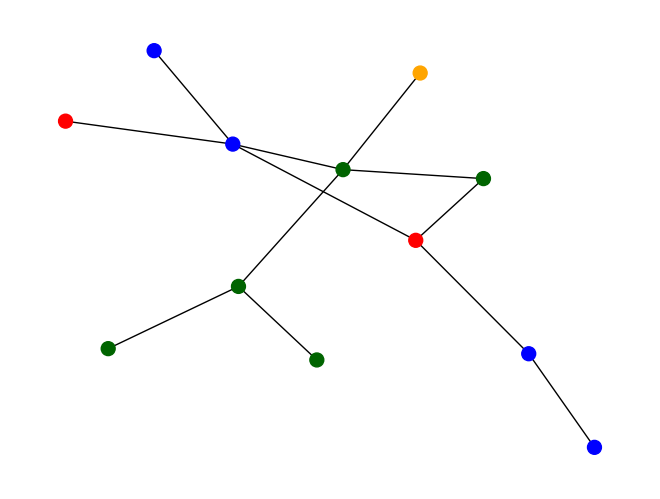

In [37]:
explanation_graph0 = plot_graph(class0_graphid, max_pred0, 0, all_edges[class0_graphid],graph_dict[class0_graphid])

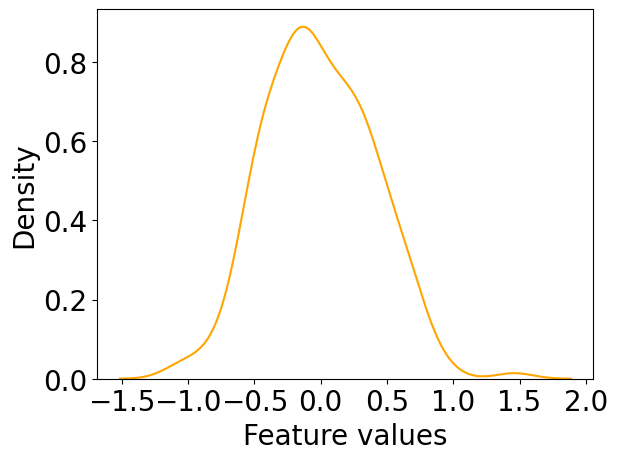

In [38]:
ind = index_2d(softmax_dict[class0_graphid], max_pred0)[0]
disease0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['disease'].numpy()[ind])
plot_node_feat(disease0_df)

In [39]:
print_stat_cont_features(disease0_df)

mean -0.009237647
std dev 0.4098495


Number of nodes:  12
graph id:  graph529
Max pred probability for class 1 is 1.0


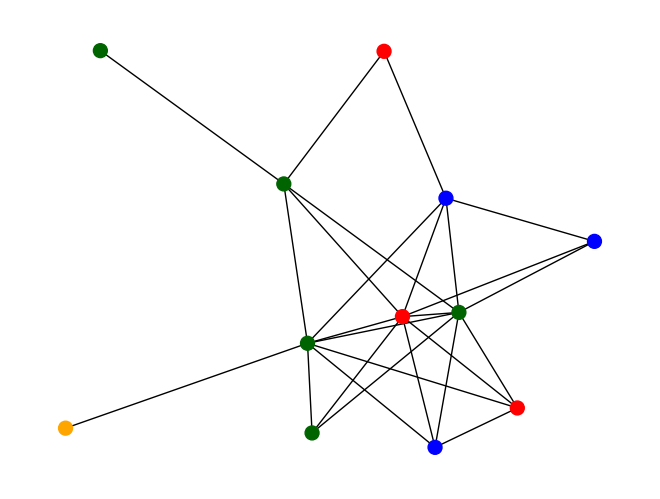

In [40]:
explanation_graph1 = plot_graph(class1_graphid, max_pred1, 1, all_edges[class1_graphid],graph_dict[class1_graphid])

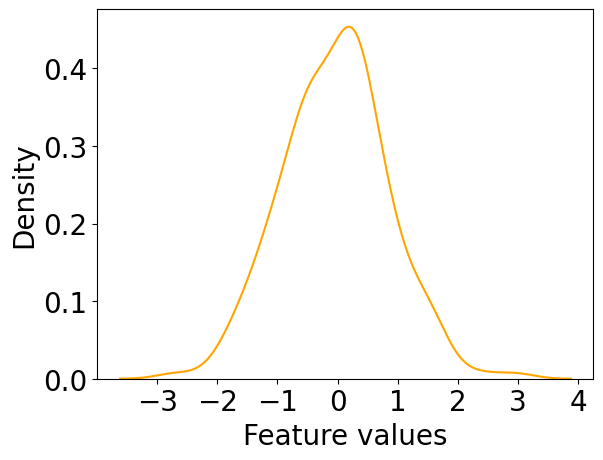

In [41]:
ind = index_2d(softmax_dict[class1_graphid], max_pred1)[0]
disease1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['disease'].numpy()[ind])
plot_node_feat(disease1_df)

In [42]:
print_stat_cont_features(disease1_df)

mean -0.037308298
std dev 0.8748441


Number of nodes:  11
graph id:  graph263
Max pred probability for class 2 is 1.0


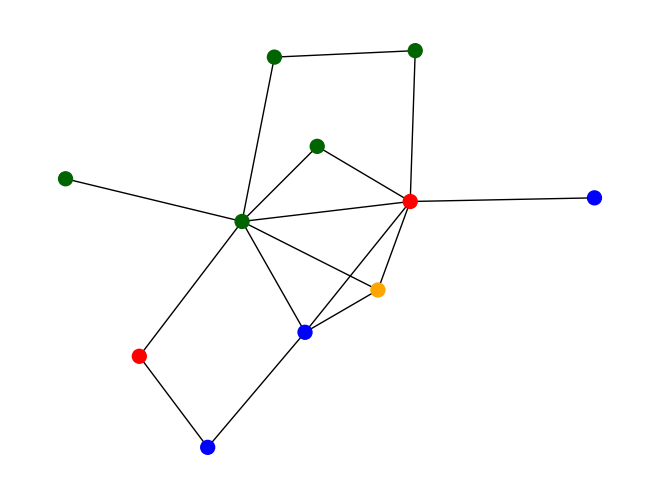

In [43]:
explanation_graph2 = plot_graph(class2_graphid, max_pred2, 2, all_edges[class2_graphid],graph_dict[class2_graphid])

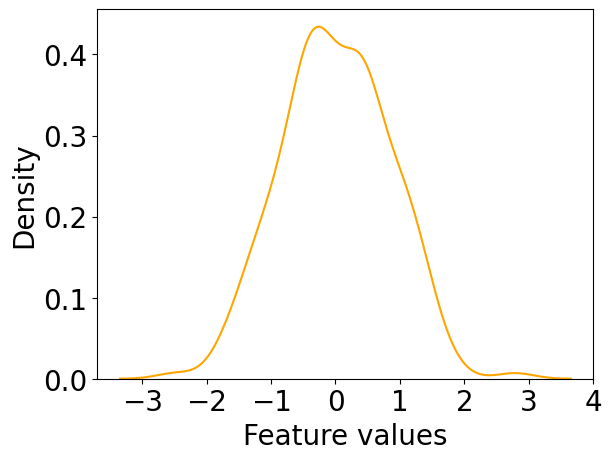

In [44]:
ind = index_2d(softmax_dict[class2_graphid], max_pred2)[0]
disease2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['disease'].numpy()[ind])
plot_node_feat(disease2_df)

In [45]:
print_stat_cont_features(disease2_df)

mean 0.00792943
std dev 0.8318124


Number of nodes:  13
graph id:  graph954
Max pred probability for class 3 is 1.0


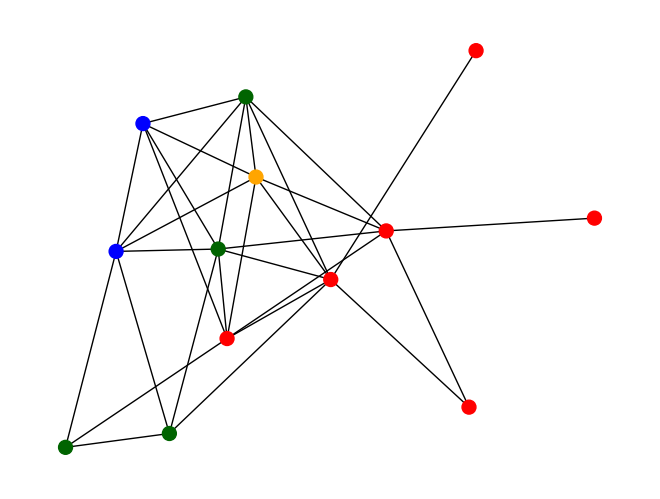

In [46]:
explanation_graph3 = plot_graph(class3_graphid, max_pred3, 3, all_edges[class3_graphid],graph_dict[class3_graphid])

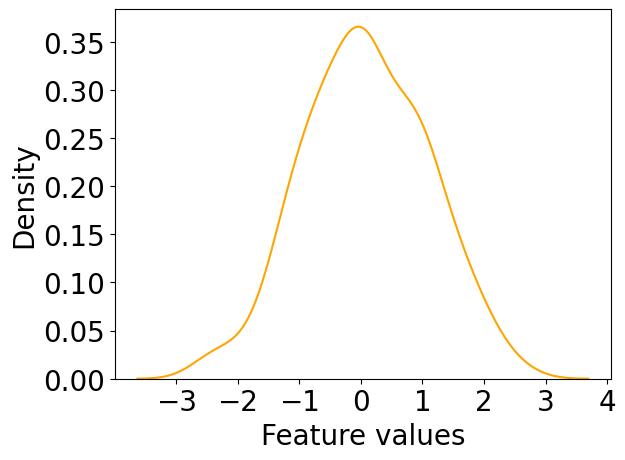

In [47]:
ind = index_2d(softmax_dict[class3_graphid], max_pred3)[0]
disease3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['disease'].numpy()[ind])
plot_node_feat(disease3_df)

In [48]:
print_stat_cont_features(disease3_df)

mean 0.083665825
std dev 1.0112426


Number of nodes:  12
graph id:  graph812
Max pred probability for class 4 is 1.0


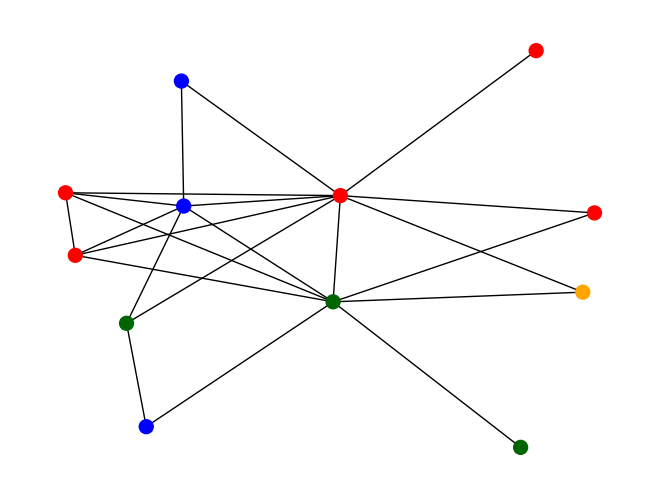

In [49]:
explanation_graph4 = plot_graph(class4_graphid, max_pred4, 4, all_edges[class4_graphid],graph_dict[class4_graphid])

Text(0, 0.5, 'Density')

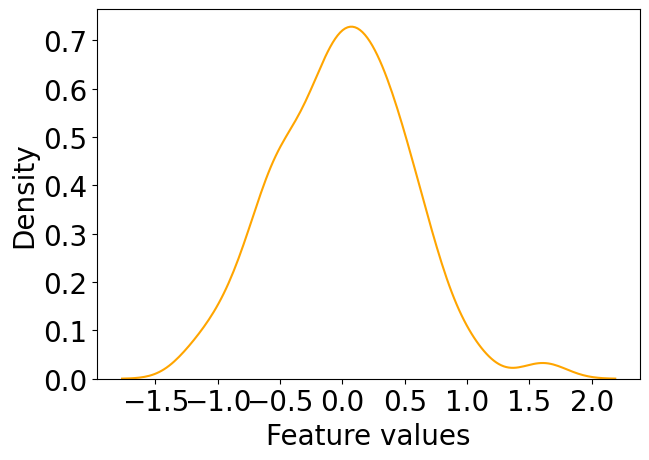

In [50]:
ind = index_2d(softmax_dict[class4_graphid], max_pred4)[0]
disease4_df = pd.DataFrame(nodefeature_dict[class4_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease4_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease4_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [51]:
print_stat_cont_features(disease4_df)

mean 0.0017027247
std dev 0.5276768


Number of nodes:  11
graph id:  graph680
Max pred probability for class 5 is 1.0


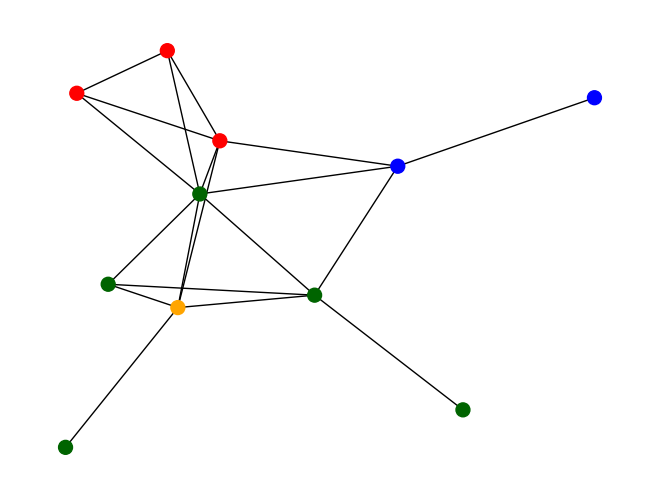

In [52]:
explanation_graph5 = plot_graph(class5_graphid, max_pred5, 5, all_edges[class5_graphid],graph_dict[class5_graphid])

Text(0, 0.5, 'Density')

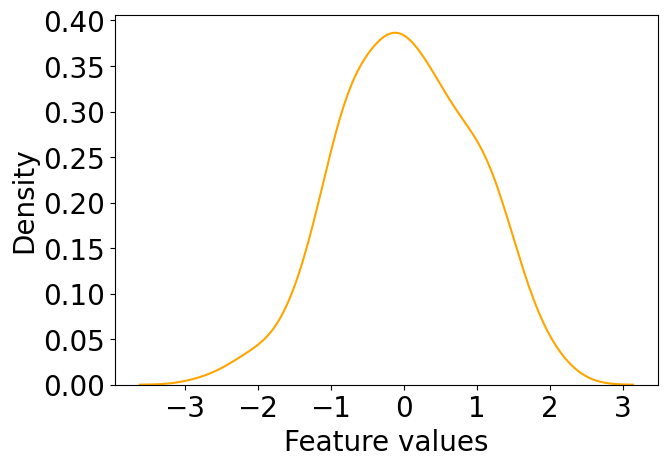

In [53]:
ind = index_2d(softmax_dict[class5_graphid], max_pred5)[0]
disease5_df = pd.DataFrame(nodefeature_dict[class5_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease5_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease5_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [54]:
print_stat_cont_features(disease5_df)

mean 0.03250242
std dev 0.92519003


Number of nodes:  11
graph id:  graph403
Max pred probability for class 6 is 1.0


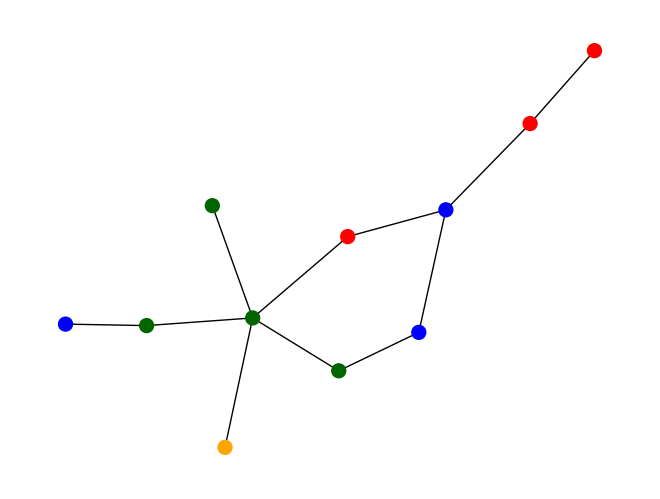

In [55]:
explanation_graph6 = plot_graph(class6_graphid, max_pred6, 6, all_edges[class6_graphid],graph_dict[class6_graphid])

Text(0, 0.5, 'Density')

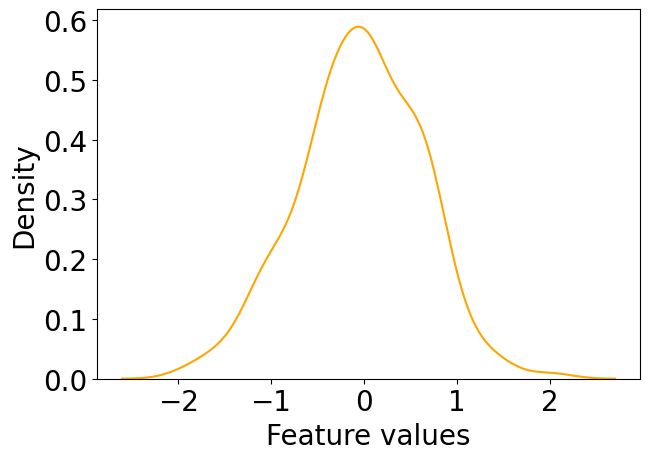

In [56]:
ind = index_2d(softmax_dict[class6_graphid], max_pred6)[0]
disease6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease6_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease6_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [57]:
print_stat_cont_features(disease6_df)

mean -0.041446876
std dev 0.6586069


Number of nodes:  8
graph id:  graph240
Max pred probability for class 7 is 1.0


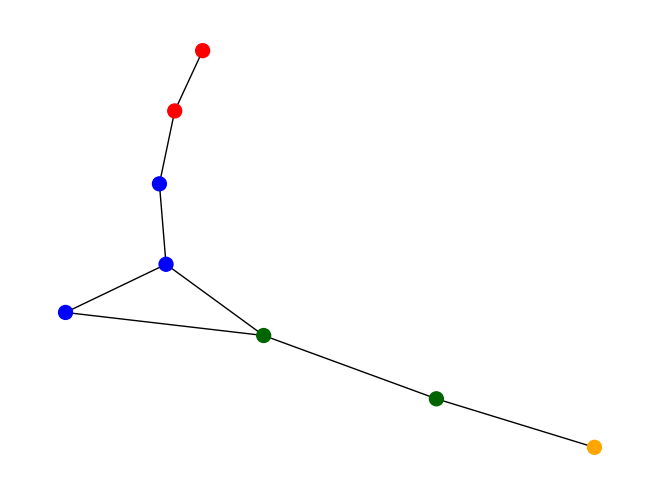

In [58]:
explanation_graph7 = plot_graph(class7_graphid, max_pred7, 7, all_edges[class7_graphid],graph_dict[class7_graphid])

Text(0, 0.5, 'Density')

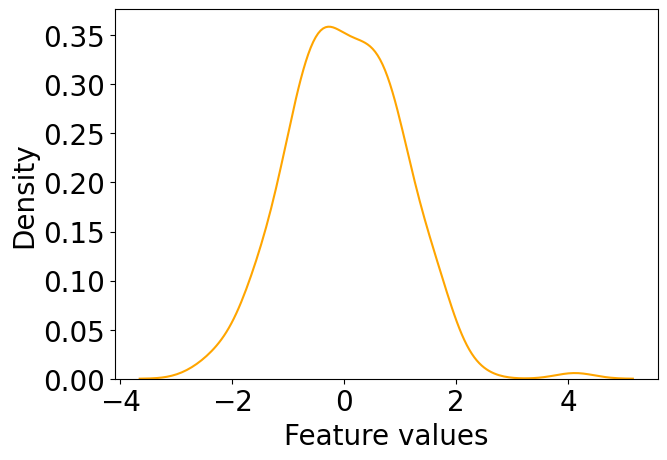

In [59]:
ind = index_2d(softmax_dict[class7_graphid], max_pred7)[0]
disease7_df = pd.DataFrame(nodefeature_dict[class7_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease7_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease7_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [60]:
print_stat_cont_features(disease7_df)

mean 0.019201586
std dev 0.9968215


In [61]:
#Gene Feature Statistics
gene0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['gene'].numpy())
print_stat_cont_features(gene0_df)

mean 0.007102209
std dev 0.28346714


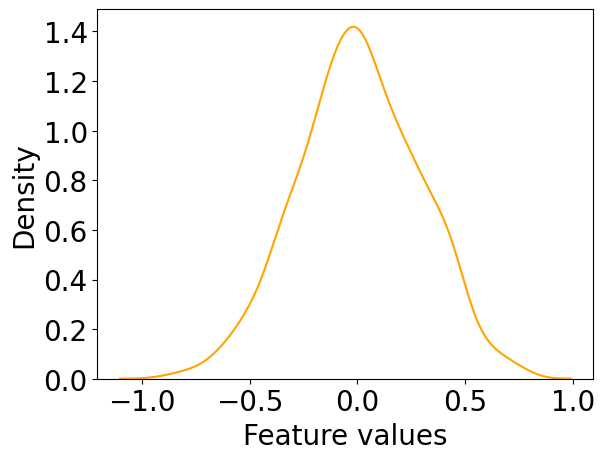

In [62]:
plot_node_feat(gene0_df)

In [63]:
gene1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['gene'].numpy())
print_stat_cont_features(gene1_df)

mean 0.009129326
std dev 0.277024


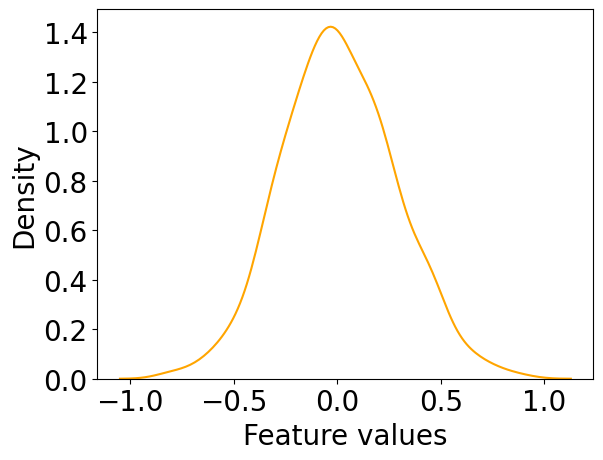

In [64]:
plot_node_feat(gene1_df)

In [65]:
gene2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['gene'].numpy())
print_stat_cont_features(gene2_df)

mean -0.0022482984
std dev 0.3074358


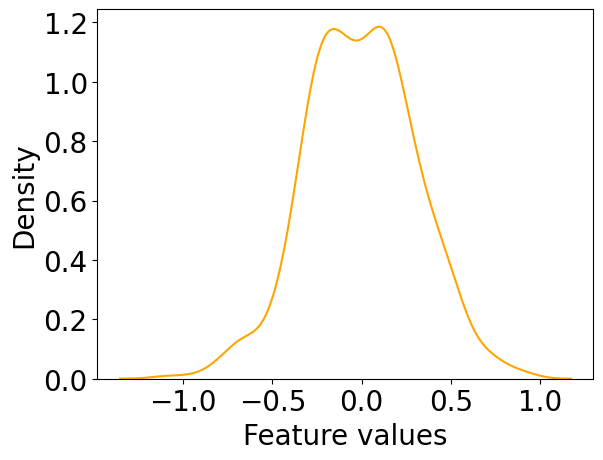

In [66]:
plot_node_feat(gene2_df)

mean 0.0076259733
std dev 0.2529483


Text(0, 0.5, 'Density')

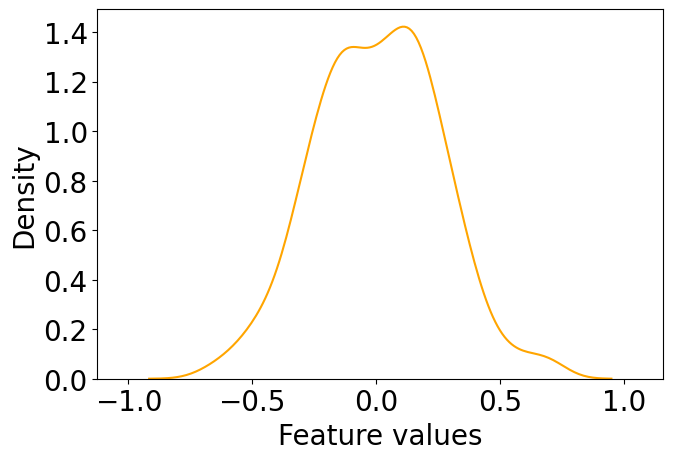

In [115]:
gene3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['gene'].numpy())
print_stat_cont_features(gene3_df)

mean 0.0076259733
std dev 0.2529483


Text(0, 0.5, 'Density')

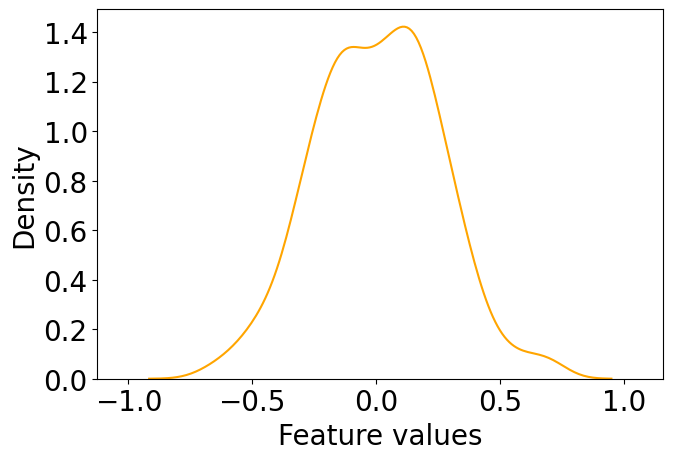

In [116]:
#plot_node_feat(gene3_df)
print_stat_cont_features(gene3_df)
fig, ax = plt.subplots(figsize=(7.3,4.8))
ax.set_aspect('equal', 'datalim')
sns.distplot(gene3_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [69]:
gene4_df = pd.DataFrame(nodefeature_dict[class4_graphid]['gene'].numpy())
print_stat_cont_features(gene4_df)

mean -0.004911156
std dev 0.26973897


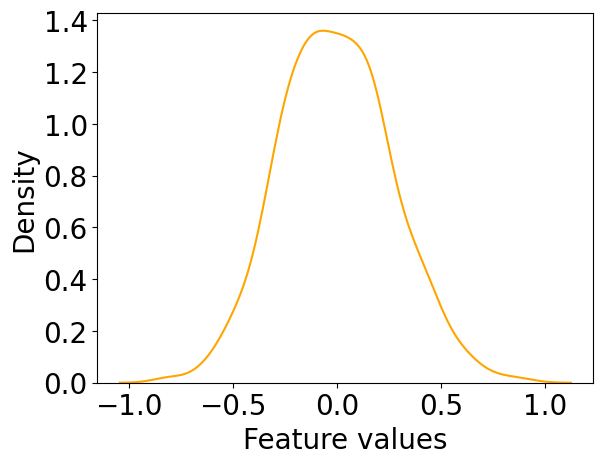

In [70]:
plot_node_feat(gene4_df)

In [71]:
gene5_df = pd.DataFrame(nodefeature_dict[class5_graphid]['gene'].numpy())
print_stat_cont_features(gene5_df)

mean 0.0028931857
std dev 0.26713172


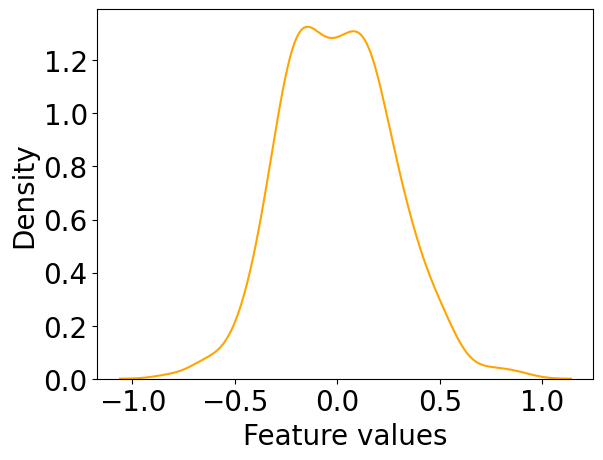

In [72]:
plot_node_feat(gene5_df)

In [73]:
gene6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['gene'].numpy())
print_stat_cont_features(gene6_df)

mean 0.0072216163
std dev 0.31273398


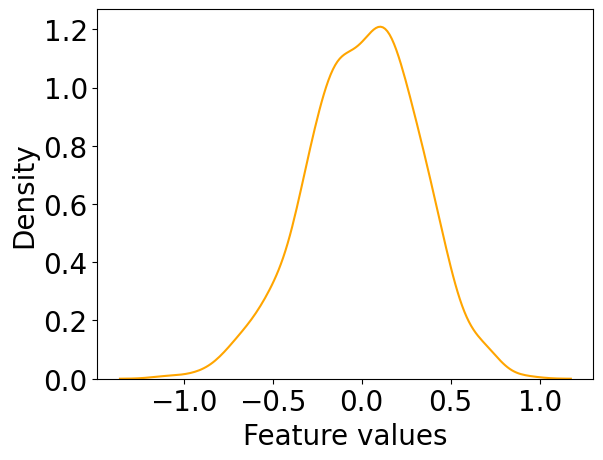

In [74]:
plot_node_feat(gene6_df)

In [75]:
gene7_df = pd.DataFrame(nodefeature_dict[class7_graphid]['gene'].numpy())
print_stat_cont_features(gene7_df)

mean -0.0008857254
std dev 0.26162672


Text(0, 0.5, 'Density')

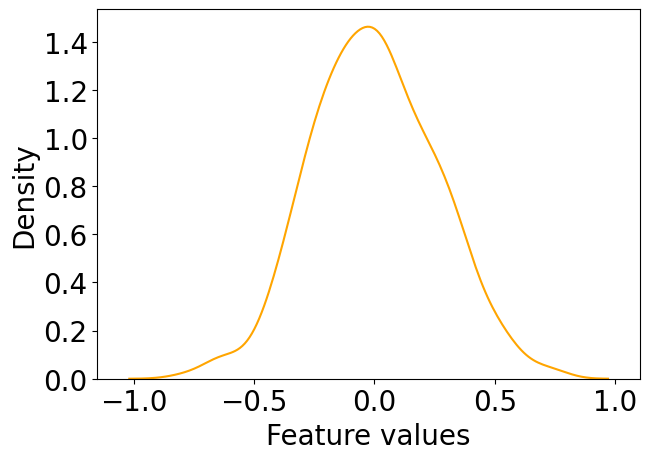

In [113]:
#plot_node_feat(gene7_df)
fig, ax = plt.subplots(figsize=(7,4.8))
ax.set_aspect('equal', 'datalim')
sns.distplot(gene7_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [77]:
#Chemical
chemical0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['chemical'].numpy())
print_stat_cont_features(chemical0_df)

mean -0.0015393439
std dev 0.2800838


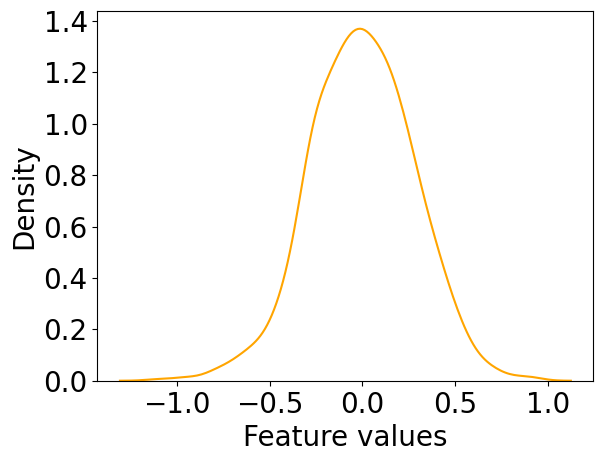

In [78]:
plot_node_feat(chemical0_df)

In [79]:
chemical1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['chemical'].numpy())
print_stat_cont_features(chemical1_df)

mean 0.0005844984
std dev 0.28398487


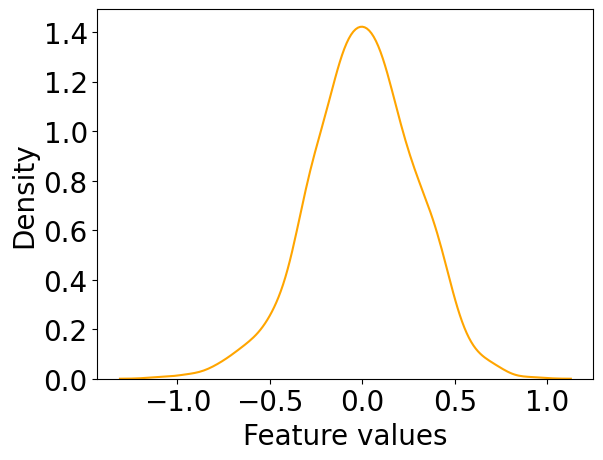

In [80]:
plot_node_feat(chemical1_df)

In [81]:
chemical2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['chemical'].numpy())
print_stat_cont_features(chemical2_df)

mean -0.0042748186
std dev 0.26794535


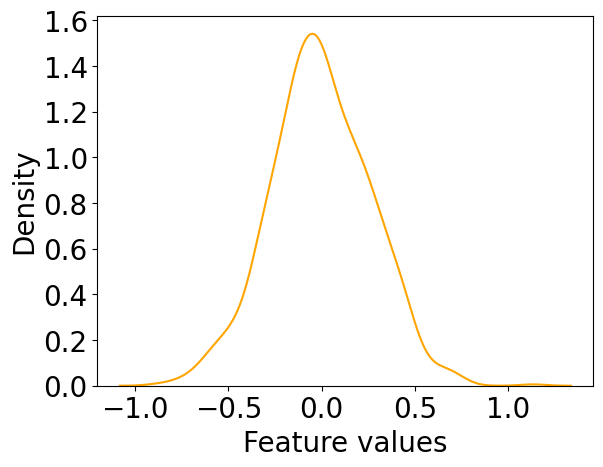

In [82]:
plot_node_feat(chemical2_df)

In [83]:
chemical3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['chemical'].numpy())
print_stat_cont_features(chemical3_df)

mean -0.005691586
std dev 0.2577145


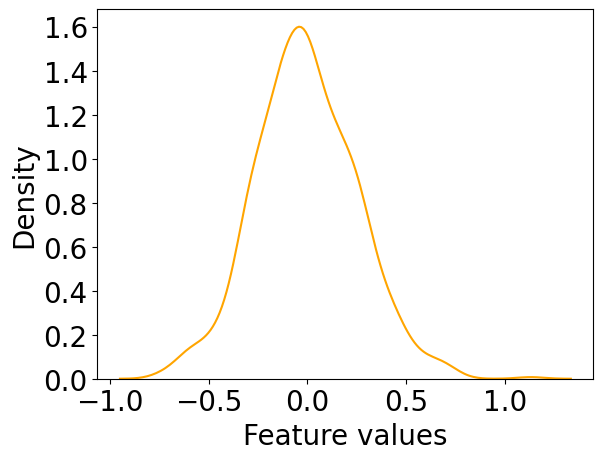

In [84]:
plot_node_feat(chemical3_df)

In [85]:
chemical4_df = pd.DataFrame(nodefeature_dict[class4_graphid]['chemical'].numpy())
print_stat_cont_features(chemical4_df)

mean 0.005699981
std dev 0.29409412


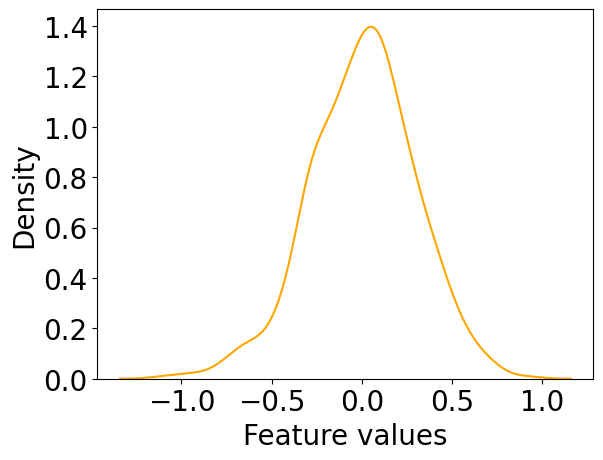

In [86]:
plot_node_feat(chemical4_df)

In [87]:
chemical5_df = pd.DataFrame(nodefeature_dict[class5_graphid]['chemical'].numpy())
print_stat_cont_features(chemical5_df)

mean 0.0010683133
std dev 0.2674806


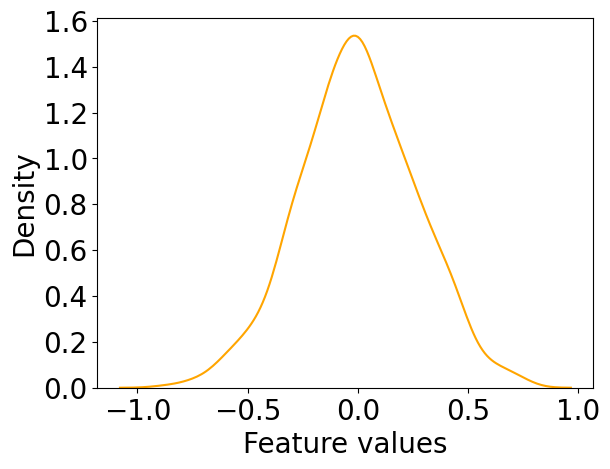

In [88]:
plot_node_feat(chemical5_df)

In [89]:
chemical6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['chemical'].numpy())
print_stat_cont_features(chemical6_df)

mean -0.0034881525
std dev 0.27952144


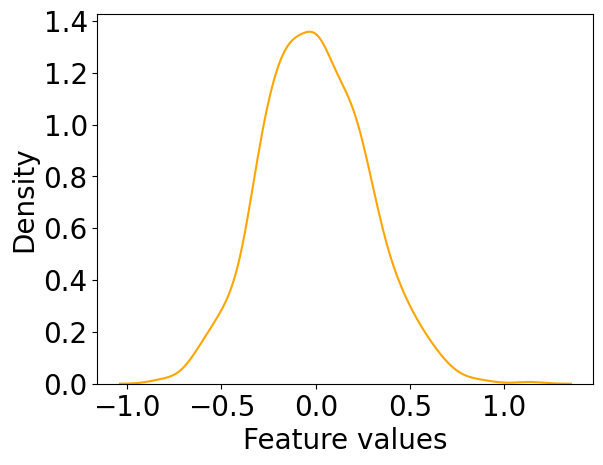

In [90]:
plot_node_feat(chemical6_df)

In [91]:
chemical7_df = pd.DataFrame(nodefeature_dict[class7_graphid]['chemical'].numpy())
print_stat_cont_features(chemical7_df)

mean 0.0051580016
std dev 0.28634953


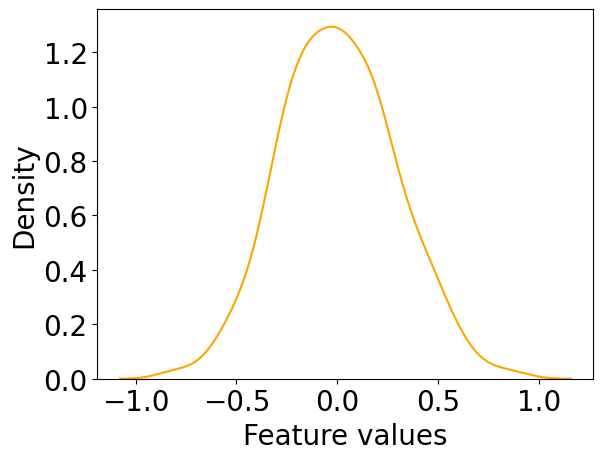

In [92]:
plot_node_feat(chemical7_df)

In [93]:
#Species
species1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['species'].numpy())
print_stat_cont_features(species1_df)

mean 0.04030142
std dev 0.26860398


Text(0, 0.5, 'Density')

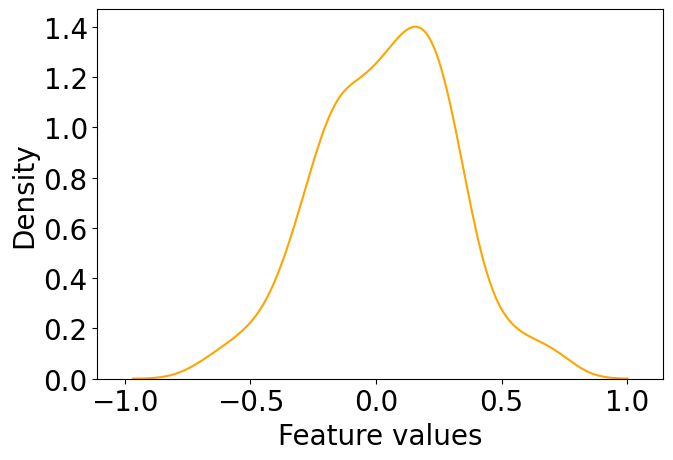

In [111]:
#plot_node_feat(species1_df)
fig, ax = plt.subplots(figsize=(7.3,4.8))
ax.set_aspect('equal', 'datalim')
sns.distplot(species1_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [95]:
species2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['species'].numpy())
print_stat_cont_features(species2_df)

mean 0.0047116987
std dev 0.31427732


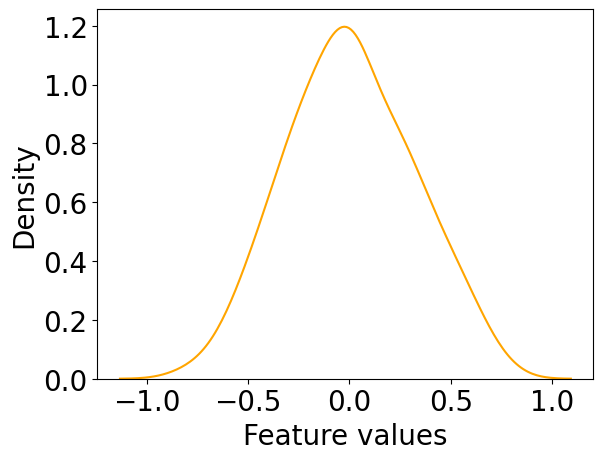

In [96]:
plot_node_feat(species2_df)

In [97]:
motifs_path = 'motif_pytorch_real/pubmed_10to15/'
files_motif = os.listdir(motifs_path)

In [104]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/pubmed_10to15/motif_real_10_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_2.gexf
motif_pytorch_real/pubmed_10

## Edit distance

In [105]:
def get_avg_edit_distance(graphid_list):
    class_avg_edit_distance = []
    for graphid in graphid_list:
        #print(graphid)
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        detect_community(expln_graph)
        list_com= nx.community.louvain_communities(expln_graph, seed=123)
        H = expln_graph.subgraph(max(list_com, key=len))
        # nx.draw(G,with_labels=True)
        # plt.show()
        edit_dist_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)
            edit_dist = nx.graph_edit_distance(H, motif_graph)
            #print(edit_dist)
            edit_dist_list.append(edit_dist)
        #print('class average', np.mean(edit_dist_list))
        class_avg_edit_distance.append(np.mean(edit_dist_list))
        
    return np.mean(class_avg_edit_distance) 

In [106]:
avg_edit_distance_list = []
for i in range(0,10):
    avg_edit_distance = get_avg_edit_distance(class_graphid_list[i])

    print('Run'+str(i),avg_edit_distance)
    avg_edit_distance_list.append(avg_edit_distance)
print(np.mean(avg_edit_distance_list))

Run0 4.516666666666667
Run1 4.966666666666667
Run2 5.491666666666667
Run3 4.708333333333334
Run4 5.2
Run5 4.216666666666667
Run6 4.925
Run7 4.141666666666667
Run8 5.116666666666667
Run9 5.016666666666667
4.83


## Fidelity

In [101]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/pubmed_10to15/motif_real_10_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_2.gexf
motif_pytorch_real/pubmed_10

In [102]:
def get_avg_fidelity(graphid_list):
    class_avg_fidelity = []
    for graphid in graphid_list:
        expln_graph = nx.Graph(all_edges[graphid])
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        # nx.draw(G,with_labels=True)
        # plt.show()
        fid_score_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)

            GM = nx.algorithms.isomorphism.GraphMatcher(expln_graph,motif_graph)
            x = 1 if GM.subgraph_is_isomorphic() else 0    
            fid_score_list.append(x)

        class_avg_fidelity.append(np.mean(fid_score_list))

    return np.mean(class_avg_fidelity) 

In [103]:
avg_fidelity_list = []

for i in range(0,10):
    avg_fidelity = get_avg_fidelity(class_graphid_list[i])

    print('Run'+str(i),avg_fidelity)
    avg_fidelity_list.append(avg_fidelity)
print(np.mean(avg_fidelity_list))

Run0 0.3
Run1 0.3416666666666666
Run2 0.30416666666666664
Run3 0.32499999999999996
Run4 0.29166666666666663
Run5 0.2958333333333333
Run6 0.31666666666666665
Run7 0.3125
Run8 0.30833333333333335
Run9 0.2958333333333333
0.3091666666666667
